# 01 — Kona vs Kaʻu Environmental Fingerprint

**Research question:** How environmentally distinct is Ka'u coffee from Kona coffee,
and which features define that identity?

**Part A — Topographic feature importance (all grid cells, per region)**
Which terrain variables best separate coffee land from non-coffee land in each region?
The classifier itself is not the product — the feature importances are.
Tells us: does Ka'u coffee occupy a different topographic niche than Kona?

**Part B — Climate fingerprint (coffee cells only, per region)**
PCA + overlapping histograms characterize the full environmental envelope of each region.
Ka'u's PC1 explains 40% of variance vs 24% for Kona — Ka'u farms have a tighter,
more coherent environmental identity. This is the core finding.

> **See notebook 04** for the analog finder and expansion suitability map,
> which build directly on these fingerprints.

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import RocCurveDisplay
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

DATA = '../data'
IMG  = '../img'
BG   = 'white'
SPLIT_LON = -155.7279

def clip_cmap(name, lo=0.0, hi=0.9):
    base = cm.get_cmap(name)
    return LinearSegmentedColormap.from_list(f'{name}_clip', base(np.linspace(lo, hi, 256)))


/home/simonhans/anaconda3/lib/python3.7/site-packages/geopandas/_compat.py:115: UserWarning: The Shapely GEOS version (3.11.4-CAPI-1.17.4) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  shapely_geos_version, geos_capi_version_string


In [2]:
# ── Load data ─────────────────────────────────────────────────────────────────
elev_feat  = pd.read_pickle(f'{DATA}/plot_elev_features.pkl')
climate_df = pd.read_pickle(f'{DATA}/df.pkl')   # 385 coffee cells, all features + region

# Assign region to elev_feat from centroid longitude
gdf_elev = gpd.GeoDataFrame(elev_feat, geometry='geometry', crs='EPSG:4326')
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    cx = gdf_elev.geometry.centroid.x
elev_feat = elev_feat.drop(columns='geometry')
elev_feat['region'] = cx.apply(lambda x: 'kona' if x < SPLIT_LON else 'kau').values

TOPO_COLS = [
    'elev_mean', 'elev_min', 'elev_max', 'elev_dev_mean',
    'slope_max', 'aspect_sin', 'aspect_cos', 'slope_x', 'slope_y',
    'curve_mean', 'pro_curve_mean', 'plan_curve_mean',
    'total_relief', 'total_relief_log', 'local_relief', 'dist_coast_m',
]

for reg in ['kona', 'kau']:
    sub = elev_feat[elev_feat.region == reg]
    n_coffee = sub.label.sum()
    print(f'{reg:6s}  total={len(sub):,}  coffee={n_coffee:,}  background={len(sub)-n_coffee:,}')

print()
for reg in ['kona', 'kau']:
    sub = climate_df[climate_df.region == reg]
    print(f'{reg:6s}  coffee cells with full features: {len(sub)}')


kona    total=7,475  coffee=409  background=7,066
kau     total=2,736  coffee=62  background=2,674

kona    coffee cells with full features: 258
kau     coffee cells with full features: 59


## Part A — Topographic Feature Importance (per region)

Random Forest trained to separate coffee vs non-coffee cells using terrain features only.
The **ROC-AUC is not the point** — we already know where the farms are.
The output we care about is feature importance: which terrain variables define
each region's coffee niche, and does that differ between Kona and Ka'u?

In [3]:
# ── Cross-validated evaluation per region ─────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {}
scalers = {}
topos  = {}

for reg in ['kona', 'kau']:
    sub = elev_feat[elev_feat.region == reg][['plot_id'] + TOPO_COLS + ['label']].dropna()
    X = sub[TOPO_COLS].values
    y = sub['label'].values
    sc = StandardScaler()
    Xs = sc.fit_transform(X)
    scalers[reg] = sc
    topos[reg]   = sub

    rf = RandomForestClassifier(n_estimators=500, class_weight='balanced',
                                max_features='sqrt', random_state=42)
    lr = LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=42)

    print(f'\n=== {reg.upper()} (n={len(sub):,}, coffee={y.sum()}) ===')
    for name, model in [('Logistic Regression', lr), ('Random Forest', rf)]:
        scores = cross_validate(model, Xs, y, cv=cv,
                                scoring=['roc_auc', 'average_precision'])
        print(f'  {name:22s}  ROC-AUC={scores["test_roc_auc"].mean():.3f}±{scores["test_roc_auc"].std():.3f}'
              f'  AvgPrec={scores["test_average_precision"].mean():.3f}±{scores["test_average_precision"].std():.3f}')

    # Fit final RF on all data
    rf.fit(Xs, y)
    models[reg] = rf



=== KONA (n=7,441, coffee=409) ===
  Logistic Regression     ROC-AUC=0.681±0.020  AvgPrec=0.103±0.013
  Random Forest           ROC-AUC=0.829±0.025  AvgPrec=0.203±0.037

=== KAU (n=2,736, coffee=62) ===
  Logistic Regression     ROC-AUC=0.738±0.064  AvgPrec=0.080±0.024
  Random Forest           ROC-AUC=0.864±0.078  AvgPrec=0.258±0.104


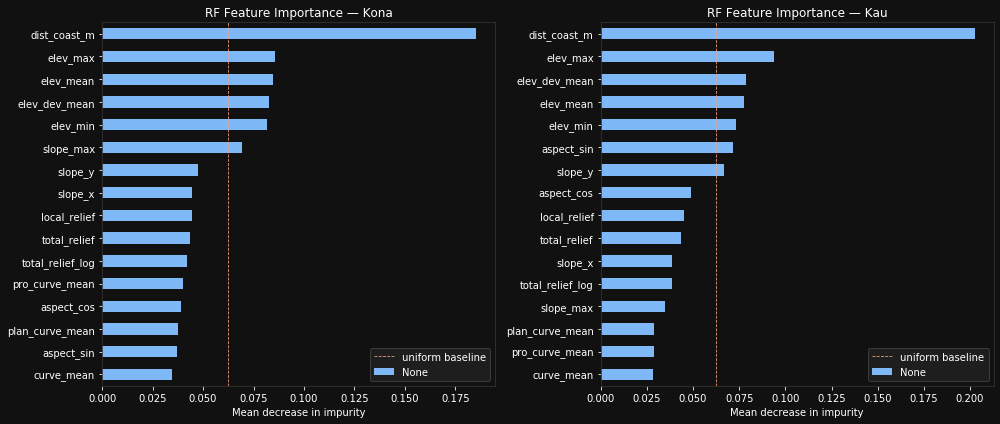

In [4]:
# ── Feature importance: Kona vs Ka'u side-by-side ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)
fig.patch.set_facecolor(BG)

for ax, reg in zip(axes, ['kona', 'kau']):
    sub = topos[reg]
    X   = sub[TOPO_COLS].values
    y   = sub['label'].values
    Xs  = scalers[reg].transform(X)
    imp = pd.Series(models[reg].feature_importances_, index=TOPO_COLS).sort_values(ascending=True)

    ax.set_facecolor(BG)
    ax.tick_params(colors='#222222')
    for spine in ax.spines.values():
        spine.set_edgecolor('#cccccc')

    imp.plot(kind='barh', ax=ax, color='#7eb8f7', edgecolor='none')
    ax.axvline(1/len(TOPO_COLS), color='#f7a07e', linestyle='--', linewidth=0.8, label='uniform baseline')
    ax.set_xlabel('Mean decrease in impurity', color='#222222')
    ax.set_title(f'RF Feature Importance — {reg.capitalize()}', color='#222222', fontsize=12)
    ax.xaxis.label.set_color('#222222')
    _leg = ax.legend(facecolor='white', edgecolor='#cccccc')
    for _t in _leg.get_texts(): _t.set_color('#222222')

plt.tight_layout()
plt.savefig(f'{IMG}/07_feature_importance.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


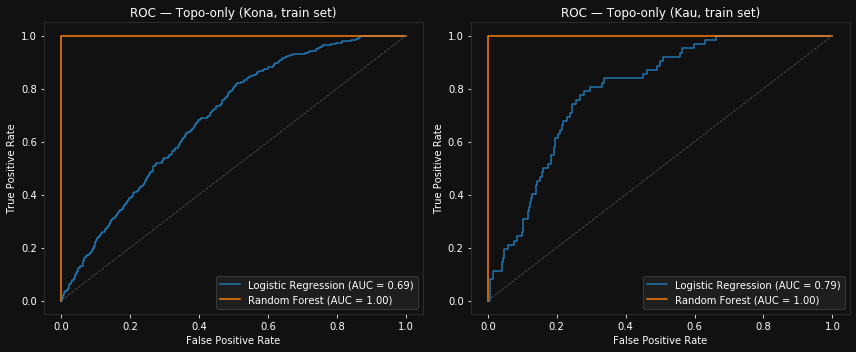

In [5]:
# ── ROC curves: Kona vs Ka'u side-by-side ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor(BG)

for ax, reg in zip(axes, ['kona', 'kau']):
    sub = topos[reg]
    X   = sub[TOPO_COLS].values
    y   = sub['label'].values
    Xs  = scalers[reg].transform(X)

    lr  = LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=42)
    lr.fit(Xs, y)

    ax.set_facecolor(BG)
    ax.tick_params(colors='#222222')
    for spine in ax.spines.values():
        spine.set_edgecolor('#cccccc')

    for name, model in [('Logistic Regression', lr), ('Random Forest', models[reg])]:
        proba = model.predict_proba(Xs)[:, 1]
        RocCurveDisplay.from_predictions(y, proba, name=name, ax=ax)

    ax.plot([0,1],[0,1], '--', color='#555555', linewidth=0.8)
    ax.set_title(f'ROC — Topo-only ({reg.capitalize()}, train set)', color='#222222', fontsize=12)
    ax.set_xlabel('False Positive Rate', color='#222222')
    ax.set_ylabel('True Positive Rate', color='#222222')
    _leg = ax.legend(facecolor='white', edgecolor='#cccccc')
    for _t in _leg.get_texts(): _t.set_color('#222222')

plt.tight_layout()
plt.savefig(f'{IMG}/07_roc.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


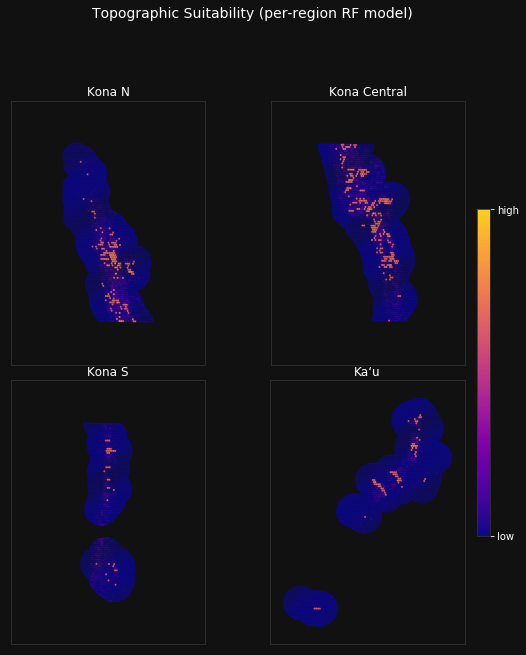

In [6]:
# ── Suitability maps — per-region model applied to per-region cells ────────────
import warnings
warnings.filterwarnings('ignore', message='Geometry is in a geographic CRS')

grid = pd.read_pickle(f'{DATA}/polygons/kona_grid.pkl')
gdf_grid = gpd.GeoDataFrame(grid, geometry='geometry', crs='EPSG:4326')
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    cx_grid = gdf_grid.geometry.centroid.x
gdf_grid['region'] = cx_grid.apply(lambda x: 'kona' if x < SPLIT_LON else 'kau').values

# Predict suitability per region using that region's trained model
prob_rows = []
for reg in ['kona', 'kau']:
    sub_grid = gdf_grid[gdf_grid.region == reg].copy()
    sub_topo = sub_grid.merge(
        elev_feat[['plot_id'] + TOPO_COLS], on='plot_id', how='left'
    ).dropna(subset=TOPO_COLS)
    Xs = scalers[reg].transform(sub_topo[TOPO_COLS].values)
    sub_topo = sub_topo.copy()
    sub_topo['rf_prob'] = models[reg].predict_proba(Xs)[:, 1]
    prob_rows.append(sub_topo[['plot_id', 'rf_prob', 'geometry']])

gdf_prob = gpd.GeoDataFrame(pd.concat(prob_rows).reset_index(drop=True), geometry='geometry', crs='EPSG:4326')

# ── 4-panel map ───────────────────────────────────────────────────────────────
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    cx = gdf_prob.geometry.centroid.x
    cy = gdf_prob.geometry.centroid.y

kona = gdf_prob[cx < SPLIT_LON]
kau  = gdf_prob[cx >= SPLIT_LON]
kona_cy = cy[kona.index]
lat_min, lat_max = kona_cy.min(), kona_cy.max()
cut1 = lat_min + (lat_max - lat_min) / 3
cut2 = lat_min + 2 * (lat_max - lat_min) / 3
kona_n = kona[kona_cy >= cut2]
kona_m = kona[(kona_cy >= cut1) & (kona_cy < cut2)]
kona_s = kona[kona_cy < cut1]

ab = kau.total_bounds
span_w = (ab[2]-ab[0]) * 1.15
span_h = (ab[3]-ab[1]) * 1.15

def centroid_bounds(r):
    b = r.total_bounds
    return (b[0]+b[2])/2, (b[1]+b[3])/2

panels = [(kona_n,'Kona N'),(kona_m,'Kona Central'),(kona_s,'Kona S'),(kau,"Kaʻu")]
cmap   = clip_cmap('plasma')
vmin, vmax = 0.0, 1.0

fig, axes = plt.subplots(2, 2, figsize=(11, 10),
                         gridspec_kw={'hspace':0.06,'wspace':0.04})
fig.patch.set_facecolor(BG)
for ax, (region, label) in zip(axes.flat, panels):
    rx, ry = centroid_bounds(region)
    ax.set_facecolor(BG)
    region.plot(ax=ax, column='rf_prob', cmap=cmap, vmin=vmin, vmax=vmax,
                legend=False, edgecolor='none', alpha=0.9)
    ax.set_xlim(rx-span_w/2, rx+span_w/2)
    ax.set_ylim(ry-span_h/2, ry+span_h/2)
    ax.set_title(label, fontsize=12, pad=5, color='#222222')
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor('#cccccc')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, shrink=0.6, pad=0.02, aspect=25)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['low', 'high'])
cbar.ax.yaxis.set_tick_params(color='#222222', labelsize=10)
for _t in cbar.ax.yaxis.get_ticklabels(): _t.set_color('#222222')
cbar.outline.set_edgecolor('#333333')
fig.suptitle('Topographic Suitability (per-region RF model)', fontsize=14, color='#222222', y=1.01)
plt.savefig(f'{IMG}/07_suitability_map.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## Part B — Climate Fingerprint

For each region, PCA on the full feature set (topo + climate + soil + NDVI)
reveals the dominant axes of environmental variation *within* each region's farms.

**Key result:** Ka'u's PC1 explains 40% of variance — nearly double Kona's 24%.
Ka'u farms are environmentally more coherent than Kona farms. They occupy a tighter,
more distinctive niche, which is consistent with Ka'u having a more uniform microclimate
and a distinctive cup profile.

In [7]:
# ── PCA on coffee cells — run separately per region ───────────────────────────
FEAT_COLS = [c for c in climate_df.columns
             if c not in ('plot_id', 'label', 'region', 'soil_null',
                          'mukey', 'muname', 'compname', 'taxorder',
                          'taxsubgrp', 'drainagecl')]

pcas = {}
Zs   = {}
for reg in ['kona', 'kau']:
    sub  = climate_df[climate_df.region == reg][FEAT_COLS].dropna()
    Xs   = StandardScaler().fit_transform(sub.values)
    pca  = PCA(n_components=min(6, len(sub)-1), random_state=42)
    Z    = pca.fit_transform(Xs)
    pcas[reg] = pca
    Zs[reg]   = Z

    var = pca.explained_variance_ratio_
    print(f'{reg.upper()} ({len(sub)} cells):')
    for i, v in enumerate(var):
        print(f'  PC{i+1}: {v:.3f}  cumulative={var[:i+1].sum():.3f}')
    print()


KONA (258 cells):
  PC1: 0.241  cumulative=0.241
  PC2: 0.198  cumulative=0.440
  PC3: 0.120  cumulative=0.559
  PC4: 0.077  cumulative=0.636
  PC5: 0.074  cumulative=0.710
  PC6: 0.061  cumulative=0.771

KAU (59 cells):
  PC1: 0.409  cumulative=0.409
  PC2: 0.159  cumulative=0.569
  PC3: 0.111  cumulative=0.680
  PC4: 0.101  cumulative=0.781
  PC5: 0.065  cumulative=0.846
  PC6: 0.045  cumulative=0.891



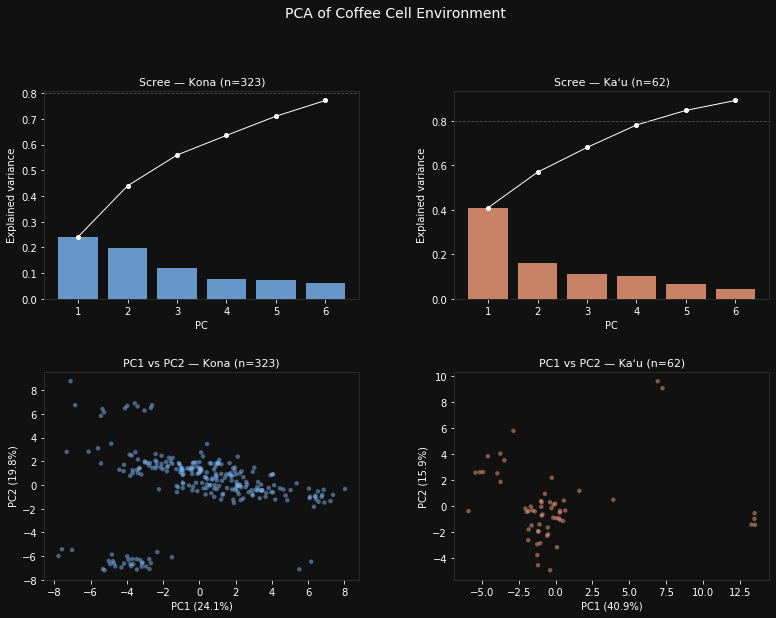

In [8]:
# ── Scree plots + PC1 vs PC2 scatter ─────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9),
                         gridspec_kw={'hspace':0.35,'wspace':0.3})
fig.patch.set_facecolor(BG)

region_labels = {'kona': 'Kona (n=323)', 'kau': "Kaʻu (n=62)"}
region_colors = {'kona': '#7eb8f7', 'kau': '#f7a07e'}

for col_idx, reg in enumerate(['kona', 'kau']):
    pca   = pcas[reg]
    Z     = Zs[reg]
    var   = pca.explained_variance_ratio_
    color = region_colors[reg]
    label = region_labels[reg]

    # Scree
    ax = axes[0, col_idx]
    ax.set_facecolor(BG)
    ax.tick_params(colors='#222222')
    for spine in ax.spines.values(): spine.set_edgecolor('#cccccc')
    ax.bar(range(1, len(var)+1), var, color=color, edgecolor='none', alpha=0.8)
    ax.plot(range(1, len(var)+1), np.cumsum(var), 'o-', color='#222222', linewidth=1, markersize=4)
    ax.axhline(0.8, color='#555555', linestyle='--', linewidth=0.8)
    ax.set_xlabel('PC', color='#222222'); ax.set_ylabel('Explained variance', color='#222222')
    ax.set_title(f'Scree — {label}', color='#222222', fontsize=11)

    # Scatter PC1 vs PC2
    ax2 = axes[1, col_idx]
    ax2.set_facecolor(BG)
    ax2.tick_params(colors='#222222')
    for spine in ax2.spines.values(): spine.set_edgecolor('#cccccc')
    ax2.scatter(Z[:,0], Z[:,1], color=color, alpha=0.5, s=20, edgecolors='none')
    ax2.set_xlabel(f'PC1 ({var[0]:.1%})', color='#222222')
    ax2.set_ylabel(f'PC2 ({var[1]:.1%})', color='#222222')
    ax2.set_title(f'PC1 vs PC2 — {label}', color='#222222', fontsize=11)

fig.suptitle('PCA of Coffee Cell Environment', color='#222222', fontsize=14, y=1.01)
plt.savefig(f'{IMG}/07_pca.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


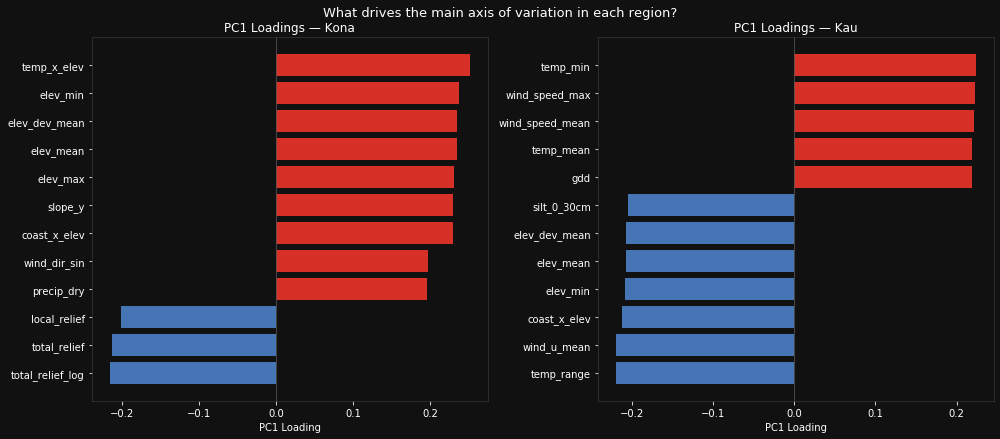

In [9]:
# ── PC1 loadings: Kona vs Ka'u ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(BG)

for ax, reg in zip(axes, ['kona', 'kau']):
    sub      = climate_df[climate_df.region == reg][FEAT_COLS].dropna()
    loadings = pd.DataFrame(pcas[reg].components_[:1].T, index=FEAT_COLS, columns=['PC1'])
    top      = loadings['PC1'].abs().sort_values(ascending=False).head(12)
    vals     = loadings.loc[top.index, 'PC1'].sort_values()
    colors   = ['#d73027' if v > 0 else '#4575b4' for v in vals]

    ax.set_facecolor(BG)
    ax.tick_params(colors='#222222')
    for spine in ax.spines.values(): spine.set_edgecolor('#cccccc')
    ax.barh(vals.index, vals.values, color=colors, edgecolor='none')
    ax.axvline(0, color='#555555', linewidth=0.8)
    ax.set_xlabel('PC1 Loading', color='#222222')
    ax.set_title(f'PC1 Loadings — {reg.capitalize()}', color='#222222', fontsize=12)

fig.suptitle('What drives the main axis of variation in each region?',
             color='#222222', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{IMG}/07_pca_loadings.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


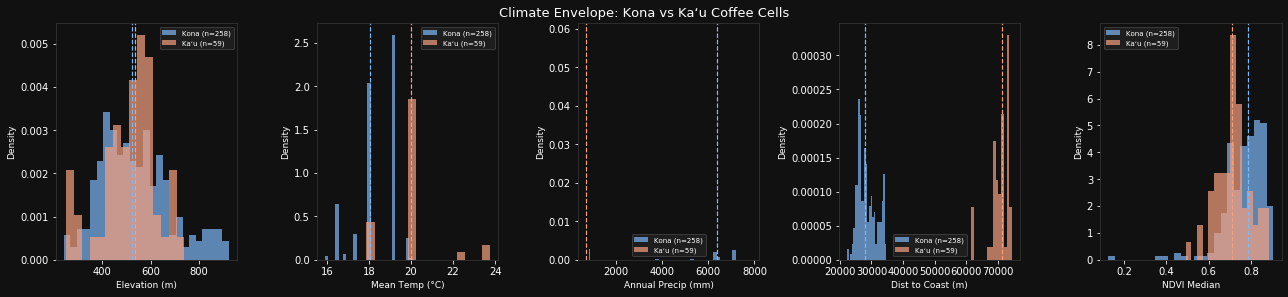

In [10]:
# ── Climate envelope: Kona vs Ka'u overlapping histograms ─────────────────────
env_cols   = ['elev_mean', 'temp_mean', 'precip_annual', 'dist_coast_m', 'ndvi_median']
env_labels = ['Elevation (m)', 'Mean Temp (°C)', 'Annual Precip (mm)',
              'Dist to Coast (m)', 'NDVI Median']

kona_df = climate_df[climate_df.region == 'kona']
kau_df  = climate_df[climate_df.region == 'kau']

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.patch.set_facecolor(BG)

for ax, col, label in zip(axes, env_cols, env_labels):
    ax.set_facecolor(BG)
    ax.tick_params(colors='#222222')
    for spine in ax.spines.values(): spine.set_edgecolor('#cccccc')

    ax.hist(kona_df[col].dropna(), bins=25, color='#7eb8f7', alpha=0.7,
            edgecolor='none', label=f'Kona (n={len(kona_df)})', density=True)
    ax.hist(kau_df[col].dropna(),  bins=15, color='#f7a07e', alpha=0.7,
            edgecolor='none', label=f"Kaʻu (n={len(kau_df)})", density=True)

    ax.axvline(kona_df[col].median(), color='#7eb8f7', linestyle='--', linewidth=1.2)
    ax.axvline(kau_df[col].median(),  color='#f7a07e', linestyle='--', linewidth=1.2)

    ax.set_xlabel(label, color='#222222', fontsize=9)
    ax.set_ylabel('Density', color='#222222', fontsize=9)
    _leg = ax.legend(facecolor='white', edgecolor='#cccccc', fontsize=7)
    for _t in _leg.get_texts(): _t.set_color('#222222')

fig.suptitle('Climate Envelope: Kona vs Kaʻu Coffee Cells', color='#222222', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{IMG}/07_climate_envelope.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
